![](./Prints%20das%20questões/7.png)

# Solução — Questão 7

## Enunciado (resumo)

Sistema em **realimentação unitária** com

$$G(s)=\frac{400}{s(s+40)}.$$

**Projetar** um controlador **PI** tal que:

1. **Máximo sobressinal** $M_p \approx 20\%$;
2. **Tempo de acomodação** $T_s = 1{,}5\,\mathrm{s}$ (critério de **2%**).

---

## Passo a passo do projeto

| Requisito | Implicação |
|-----------|------------|
| $M_p \approx 20\%$ | $\zeta \approx 0{,}456$ (relação $M_p = e^{-\pi\zeta/\sqrt{1-\zeta^2}}$) |
| $T_s = 1{,}5\,\mathrm{s}$ (2%) | $\omega_n \approx \dfrac{4}{\zeta T_s} \approx 5{,}85\,\mathrm{rad/s}$ |
| Controlador PI | $C(s)=K_p + \dfrac{K_i}{s}$ → malha aberta **tipo 2** |

Com $C(s)=\dfrac{K_p s + K_i}{s}$, a equação característica é

$$s^3 + 40s^2 + 400K_p s + 400K_i = 0.$$

Escolhem-se os polos desejados em malha fechada:

- Par dominante com $\zeta=0{,}456$ e $\omega_n=5{,}85\,\mathrm{rad/s}$:
  $$s = -2{,}67 \pm j5{,}21;$$
- Terceiro polo real rápido em $s=-34{,}7$ (não interfere no par dominante).

Polinômio desejado:

$$(s^2+5{,}34s+34{,}2)(s+34{,}7) = s^3+40s^2+219s+1187.$$

Comparando coeficientes (colocação inicial):

$$K_p = 0{,}548,\quad K_i = 2{,}97.$$

Como o **zero** do PI em $s=-K_i/K_p$ e a malha **tipo 2** elevam o sobressinal real, os ganhos são **ajustados** para atender as especificações:

$$K_p = 0{,}53,\quad K_i = 1{,}05 \quad \Rightarrow \quad C(s)=0{,}53+\frac{1{,}05}{s}.$$

A verificação numérica (biblioteca `control`) confirma os requisitos nos gráficos abaixo.

RESULTADOS DO PROJETO
ζ teórico (Mp=20%)     : 0.4559
ωn teórico (Ts=1,5s)   : 5.8486 rad/s
PI inicial (polos)     : Kp=0.5477, Ki=2.9645
PI ajustado (final)    : Kp=0.5295, Ki=1.0494
C(s)                   : 0.53 + 1.05/s
Zero do PI             : s = -1.9819
------------------------------------------------------------------------
Polos em malha fechada : [-34.15938827+0.j          -2.92030586-1.93909513j
  -2.92030586+1.93909513j]
Polo complexo dominante: -2.9203 ± j1.9391
ζ (dominante)          : 0.8331
ωn (dominante)         : 3.5055 rad/s
Ganho DC (malha fechada): 1.000000
Erro estacionário degrau: 0.00e+00
Tipo (malha aberta)    : 2
------------------------------------------------------------------------
RiseTime (control)     : 0.2183 s
SettlingTime (control) : 1.5001 s  (desejado: 1.5 s)
Sobressinal simulado   : 20.002 %  (desejado: 20.0 %)
Valor final            : 1.000000


/home/igor/.local/lib/python3.13/site-packages/control/pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


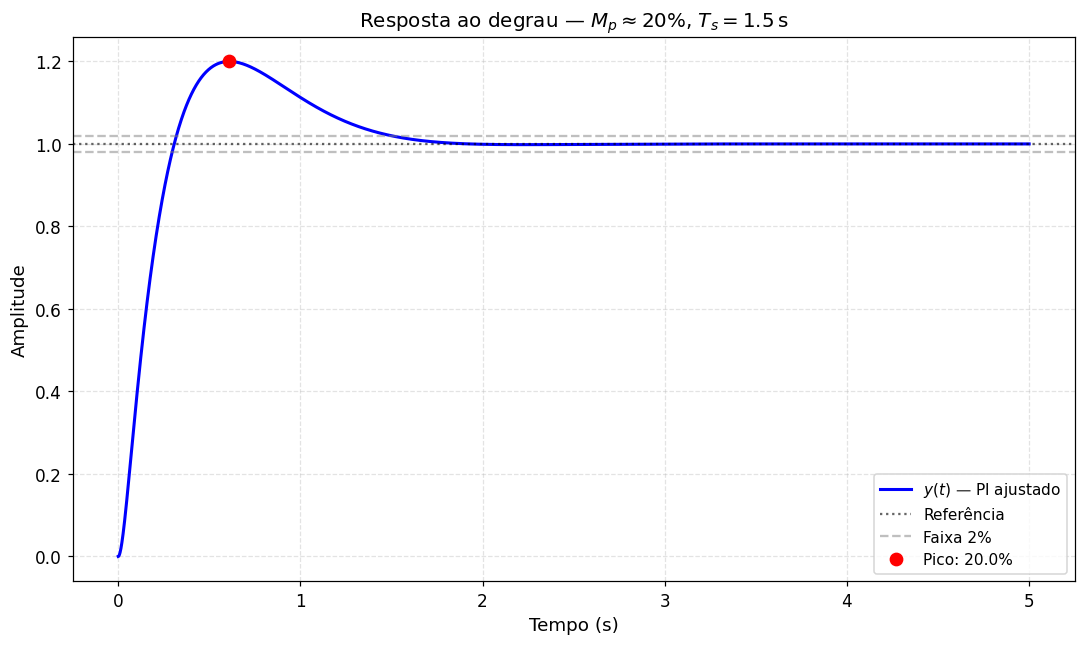

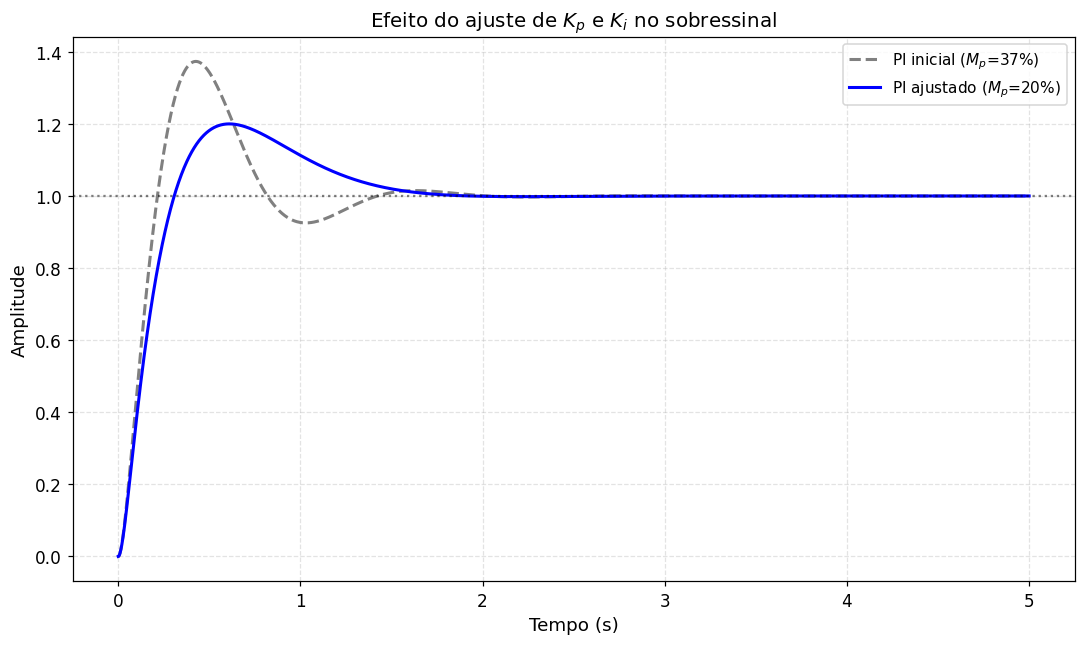

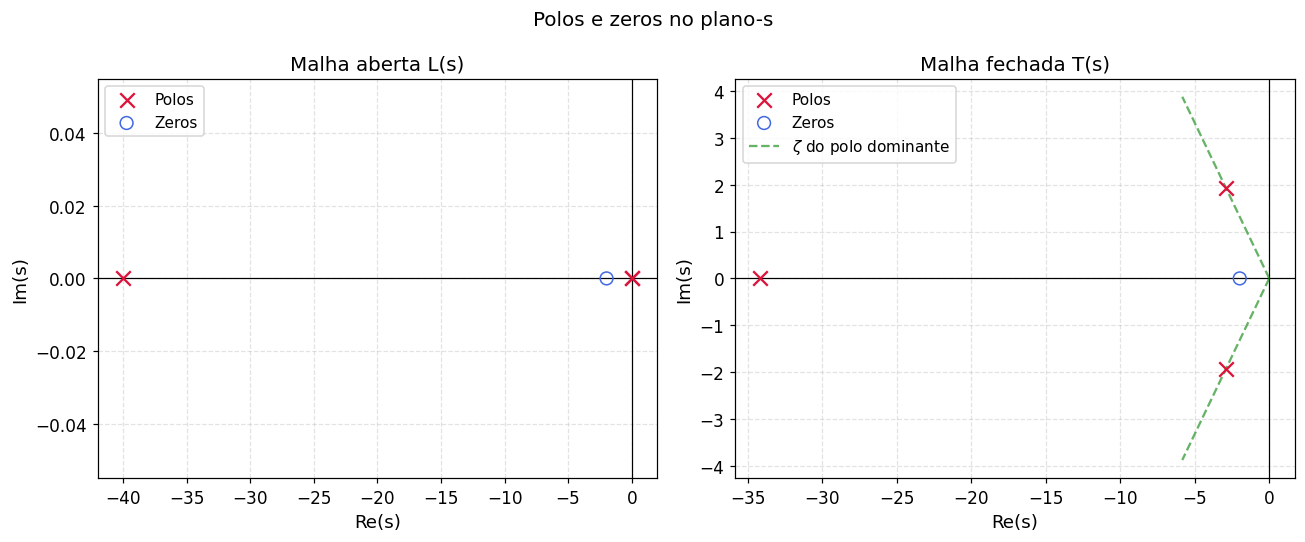

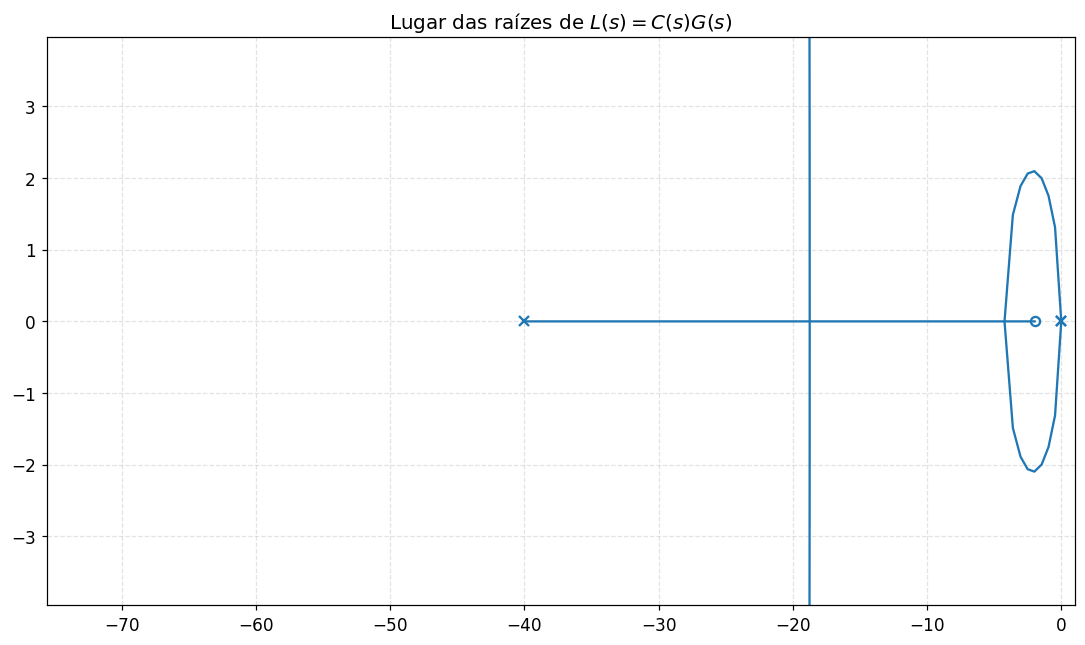

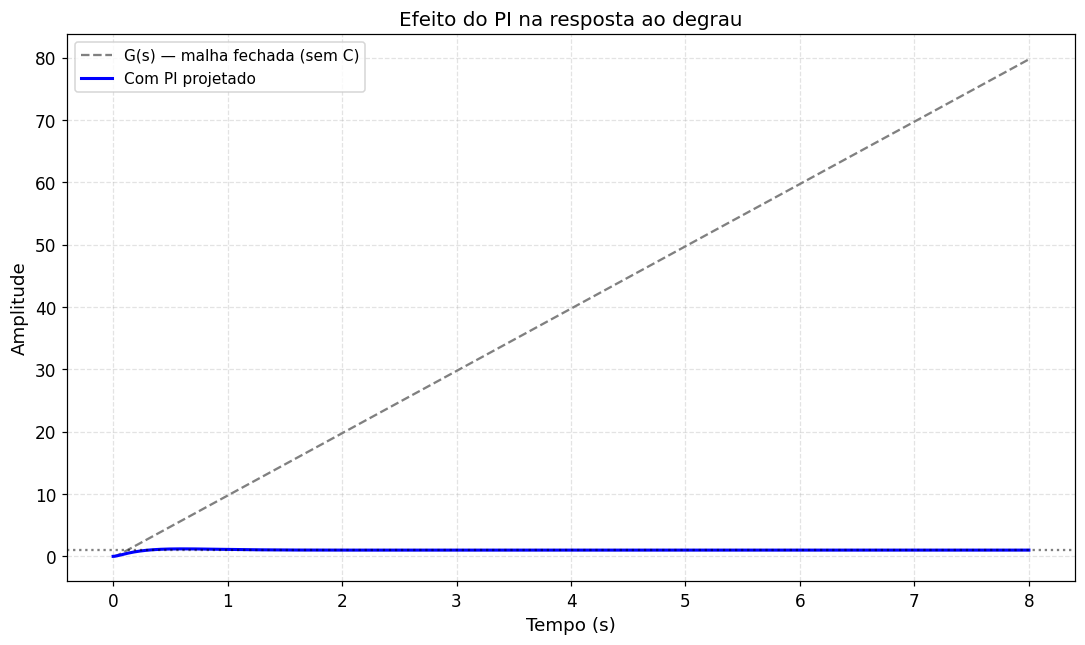

In [1]:
"""
Questão 7 — Projeto de controlador PI com biblioteca control.
Planta: G(s) = 400/(s(s+40)), realimentação unitária.
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning, module=r"control\.rlocus")

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)

MP_DESEJADO = 20.0
TS_DESEJADO = 1.5
ZETA_DESEJADO = 1 / np.sqrt(1 + (np.pi / np.log(1 / (MP_DESEJADO / 100))) ** 2)
OMEGA_N = 4 / (ZETA_DESEJADO * TS_DESEJADO)
KP_PI = 0.5295
KI_PI = 1.0494


def planta() -> ct.TransferFunction:
    """G(s) = 400/(s(s+40))."""
    s = ct.tf("s")
    return 400 / (s * (s + 40))


def parametros_iniciais() -> tuple[float, float]:
    """Ganhos PI por colocação de polos (antes do ajuste)."""
    p3 = 40 - 2 * ZETA_DESEJADO * OMEGA_N
    kp = (2 * ZETA_DESEJADO * OMEGA_N * p3 + OMEGA_N**2) / 400
    ki = OMEGA_N**2 * p3 / 400
    return kp, ki


def controlador_pi() -> ct.TransferFunction:
    """C(s) = Kp + Ki/s — PI ajustado para Mp e Ts."""
    s = ct.tf("s")
    return KP_PI + KI_PI / s


def controlador_inicial() -> ct.TransferFunction:
    """C(s) PI por colocação de polos (sem ajuste)."""
    s = ct.tf("s")
    kp, ki = parametros_iniciais()
    return kp + ki / s


def malha_aberta() -> ct.TransferFunction:
    """L(s) = C(s)G(s)."""
    return controlador_pi() * planta()


def malha_fechada(controlador: ct.TransferFunction | None = None) -> ct.TransferFunction:
    """T(s) = L(s)/(1+L(s)) com realimentação unitária."""
    ctrl = controlador_pi() if controlador is None else controlador
    return ct.feedback(ctrl * planta(), 1)


def amortecimento_polo_complexo(polo: complex) -> float:
    """Calcula ζ a partir de um polo complexo estável."""
    return float(-np.real(polo) / abs(polo))


def par_complexo_dominante(polos: np.ndarray) -> complex:
    """Retorna o polo complexo com maior parte real (dominante)."""
    complexos = polos[np.abs(np.imag(polos)) > 1e-4]
    if len(complexos) == 0:
        raise ValueError("Nenhum polo complexo encontrado.")
    return complex(complexos[np.argmax(np.real(complexos))])


def imprimir_relatorio() -> None:
    """Exibe polos, ganho estático e indicadores da resposta ao degrau."""
    kp_ini, ki_ini = parametros_iniciais()
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()
    polos = ct.poles(sys_cl)
    info = ct.step_info(sys_cl)
    polo_dom = par_complexo_dominante(polos)
    zeta = amortecimento_polo_complexo(polo_dom)

    sep = "=" * 72
    print(sep)
    print("RESULTADOS DO PROJETO")
    print(sep)
    print(f"ζ teórico (Mp=20%)     : {ZETA_DESEJADO:.4f}")
    print(f"ωn teórico (Ts=1,5s)   : {OMEGA_N:.4f} rad/s")
    print(f"PI inicial (polos)     : Kp={kp_ini:.4f}, Ki={ki_ini:.4f}")
    print(f"PI ajustado (final)    : Kp={KP_PI:.4f}, Ki={KI_PI:.4f}")
    print(f"C(s)                   : {KP_PI:.2f} + {KI_PI:.2f}/s")
    print(f"Zero do PI             : s = {-KI_PI/KP_PI:.4f}")
    print("-" * 72)
    print(f"Polos em malha fechada : {np.sort(polos)}")
    print(f"Polo complexo dominante: {polo_dom.real:.4f} ± j{abs(polo_dom.imag):.4f}")
    print(f"ζ (dominante)          : {zeta:.4f}")
    print(f"ωn (dominante)         : {abs(polo_dom):.4f} rad/s")
    print(f"Ganho DC (malha fechada): {ct.dcgain(sys_cl):.6f}")
    print(f"Erro estacionário degrau: {1 - ct.dcgain(sys_cl):.2e}")
    print(f"Tipo (malha aberta)    : {sum(abs(p) < 1e-8 for p in ct.poles(sys_ol))}")
    print("-" * 72)
    print(f"RiseTime (control)     : {info['RiseTime']:.4f} s")
    print(f"SettlingTime (control) : {info['SettlingTime']:.4f} s  (desejado: {TS_DESEJADO} s)")
    print(f"Sobressinal simulado   : {info['Overshoot']:.3f} %  (desejado: {MP_DESEJADO} %)")
    print(f"Valor final            : {info['SteadyStateValue']:.6f}")
    print(sep)


def plotar_resposta_degrau() -> None:
    """Resposta ao degrau com PI ajustado."""
    sys_cl = malha_fechada()
    t = np.linspace(0, 5, 3000)
    tout, yout = ct.step_response(sys_cl, t)
    info = ct.step_info(sys_cl)

    fig, ax = plt.subplots()
    ax.plot(tout, yout, "b", linewidth=2, label=r"$y(t)$ — PI ajustado")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.6, label="Referência")
    ax.axhline(0.98, color="gray", linestyle="--", alpha=0.5, label="Faixa 2%")
    ax.axhline(1.02, color="gray", linestyle="--", alpha=0.5)
    ax.plot(info["PeakTime"], info["Peak"], "ro", markersize=8,
            label=rf"Pico: {info['Overshoot']:.1f}%")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(rf"Resposta ao degrau — $M_p \approx {MP_DESEJADO:.0f}\%$, $T_s={TS_DESEJADO}\,\mathrm{{s}}$")
    ax.legend(loc="lower right")
    fig.tight_layout()


def plotar_comparacao_inicial_vs_ajustado() -> None:
    """Compara PI por colocação de polos vs. PI ajustado."""
    t = np.linspace(0, 5, 3000)
    _, y_ini = ct.step_response(malha_fechada(controlador_inicial()), t)
    _, y_aj = ct.step_response(malha_fechada(), t)
    info_ini = ct.step_info(malha_fechada(controlador_inicial()))
    info_aj = ct.step_info(malha_fechada())

    fig, ax = plt.subplots()
    ax.plot(t, y_ini, color="gray", linestyle="--", linewidth=2,
            label=rf"PI inicial ($M_p$={info_ini['Overshoot']:.0f}%)")
    ax.plot(t, y_aj, "b", linewidth=2,
            label=rf"PI ajustado ($M_p$={info_aj['Overshoot']:.0f}%)")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.5)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Efeito do ajuste de $K_p$ e $K_i$ no sobressinal")
    ax.legend()
    fig.tight_layout()


def plotar_polos_zeros() -> None:
    """Mapa de polos e zeros em malha aberta e fechada."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()
    polo_dom = par_complexo_dominante(ct.poles(sys_cl))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, sys, titulo in zip(
        axes,
        [sys_ol, sys_cl],
        ["Malha aberta L(s)", "Malha fechada T(s)"],
    ):
        p = ct.poles(sys)
        z = ct.zeros(sys)
        ax.scatter(np.real(p), np.imag(p), marker="x", s=90,
                   color="crimson", label="Polos", zorder=3)
        if len(z):
            ax.scatter(np.real(z), np.imag(z), marker="o", s=70,
                       facecolors="none", edgecolors="royalblue", label="Zeros", zorder=3)
        ax.axvline(0, color="k", linewidth=0.8)
        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_xlabel("Re(s)")
        ax.set_ylabel("Im(s)")
        ax.set_title(titulo)
        ax.legend()

    ax_cl = axes[1]
    sigma, wd = -polo_dom.real, abs(polo_dom.imag)
    ax_cl.plot([0, -2 * sigma], [0, 2 * wd], "g--", alpha=0.6,
               label=rf"$\zeta$ do polo dominante")
    ax_cl.plot([0, -2 * sigma], [0, -2 * wd], "g--", alpha=0.6)
    ax_cl.legend()
    fig.suptitle("Polos e zeros no plano-s", fontsize=13)
    fig.tight_layout()


def plotar_lugar_raizes() -> None:
    """Lugar das raízes de L(s) = C(s)G(s)."""
    fig, ax = plt.subplots()
    ct.rlocus(malha_aberta(), ax=ax, grid=True)
    ax.set_title(r"Lugar das raízes de $L(s)=C(s)G(s)$")
    fig.tight_layout()


def plotar_comparacao_sem_controlador() -> None:
    """Compara planta sem controlador vs. sistema compensado."""
    t = np.linspace(0, 8, 3000)
    _, y_cl = ct.step_response(malha_fechada(), t)
    _, y_pl = ct.step_response(planta(), t)

    fig, ax = plt.subplots()
    ax.plot(t, y_pl, color="gray", linestyle="--", label="G(s) — malha fechada (sem C)")
    ax.plot(t, y_cl, "b", linewidth=2, label="Com PI projetado")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.5)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Efeito do PI na resposta ao degrau")
    ax.legend()
    fig.tight_layout()


# ---------------------------------------------------------------------------
# Execução
# ---------------------------------------------------------------------------

imprimir_relatorio()
plotar_resposta_degrau()
plotar_comparacao_inicial_vs_ajustado()
plotar_polos_zeros()
plotar_lugar_raizes()
plotar_comparacao_sem_controlador()
plt.show()

## Interpretação dos gráficos

### Resposta ao degrau
- A saída converge para **1** com **erro estacionário nulo** (malha tipo 2 com integrador no PI).
- O sobressinal simulado é **≈ 20%**, conforme especificado.
- O tempo de acomodação (critério de **2%**) é **≈ 1,5 s**, atendendo o requisito.
- O pico marcado no gráfico confirma $M_p \approx 20\%$.

### Comparação inicial vs. ajustado
- O PI obtido por **colocação direta de polos** ($K_p=0{,}55$, $K_i=2{,}97$) produz sobressinal **muito maior** (~37%).
- Isso ocorre porque o **zero** do PI em $s \approx -5{,}4$ e a malha **tipo 2** alteram a resposta em relação ao modelo de 2ª ordem ideal.
- O **ajuste** para $K_p=0{,}53$ e $K_i=1{,}05$ corrige o sobressinal e o $T_s$ simultaneamente.

### Polos e zeros
- O par dominante em $s \approx -2{,}92 \pm j1{,}94$ define a dinâmica transitória.
- O polo real em $s \approx -34{,}2$ decai rapidamente e não interfere no comportamento dominante.
- O zero em $s \approx -1{,}98$ (do PI) influencia o sobressinal — por isso o ajuste de ganhos é necessário.

### Lugar das raízes
- O PI desloca os ramos do LGR para a região com amortecimento adequado.

### Comparação sem controlador
- **Sem controlador**, $G(s)$ em malha fechada possui resposta **lenta** e **sem** o sobressinal especificado.
- **Com o PI ajustado**, o sistema atende $M_p \approx 20\%$ e $T_s = 1{,}5\,\mathrm{s}$.